## Install Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap ipywidgets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.5 MB/s eta 0:00:00


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import shap
import ipywidgets as widgets
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Load Dataset

In [3]:
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('UNSW_NB15_testing-set.csv')

print(f'Training set shape : {train_df.shape}')
print(f'Testing set shape  : {test_df.shape}')

Training set shape : (82332, 45)
Testing set shape  : (175341, 45)


In [4]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.0000,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0000,0.0000,0,0,0.0110,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.0000,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0000,0.0000,0,0,0.0080,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.0000,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0000,0.0000,0,0,0.0050,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.0000,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0000,0.0000,0,0,0.0060,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.0000,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0000,0.0000,0,0,0.0100,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


In [5]:
test_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.1215,tcp,-,FIN,6,4,258,172,74.0875,252,254,14158.9424,8495.3652,0,0,24.2956,8.3750,30.1775,11.8306,255,621772692,2202533631,255,0.0000,0.0000,0.0000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.6499,tcp,-,FIN,14,38,734,42014,78.4734,62,252,8395.1123,503571.3125,2,17,49.9150,15.4329,61.4269,1387.7783,255,1417884146,3077387971,255,0.0000,0.0000,0.0000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.6231,tcp,-,FIN,8,16,364,13186,14.1702,62,252,1572.2719,60929.2305,1,6,231.8756,102.7372,17179.5869,11420.9262,255,2116150707,2963114973,255,0.1119,0.0615,0.0504,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.6816,tcp,ftp,FIN,12,12,628,770,13.6771,62,252,2740.1790,3358.6221,1,3,152.8765,90.2357,259.0802,4991.7847,255,1107119177,1047442890,255,0.0000,0.0000,0.0000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.4495,tcp,-,FIN,10,6,534,268,33.3738,254,252,8561.4990,3987.0598,2,1,47.7503,75.6596,2415.8376,115.8070,255,2436137549,1977154190,255,0.1284,0.0711,0.0572,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


## Exploratory Data Analysis (EDA)

### Dataset Overview

In [61]:
print('Training Set Info')
train_df.info()

Training Set Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinp

In [7]:
train_df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000,82332.0000
mean,41166.5000,1.0068,18.6665,17.5459,7993.9082,13233.7856,82410.8867,180.9677,95.7130,64549016.9141,630546.9590,4.7537,6.3086,755.3943,121.7013,6363.0751,535.1804,133.4591,1084641551.1153,1073464670.8804,128.2866,0.0559,0.0293,0.0267,139.5286,116.2751,0.0943,1595.3719,9.5466,1.3693,5.7449,4.9289,3.6630,7.4564,0.0083,0.0084,0.1297,6.4684,9.1643,0.0111,0.5506
std,23767.3455,4.7104,133.9164,115.5741,171642.2619,151471.4561,148620.3670,101.5134,116.6677,179861832.6300,2393000.5556,64.6496,55.7080,6182.6157,1292.3785,56724.0167,3635.3054,127.3570,1390859761.6104,1381996192.0327,127.4914,0.1160,0.0709,0.0551,208.4721,244.6003,0.5429,38066.9723,11.0903,1.0672,8.4181,8.3895,5.9154,11.4152,0.0912,0.0925,0.6387,8.5439,11.1214,0.1049,0.4974
min,1.0000,0.0000,1.0000,0.0000,24.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,24.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000
25%,20583.7500,0.0000,2.0000,0.0000,114.0000,0.0000,28.6061,62.0000,0.0000,11202.4668,0.0000,0.0000,0.0000,0.0080,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,57.0000,0.0000,0.0000,0.0000,2.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,2.0000,0.0000,0.0000
50%,41166.5000,0.0141,6.0000,2.0000,534.0000,178.0000,2650.1767,254.0000,29.0000,577003.2188,2112.9514,1.0000,0.0000,0.5579,0.0100,17.6239,0.0000,255.0000,27888855.0000,28569748.5000,255.0000,0.0006,0.0004,0.0001,65.0000,44.0000,0.0000,0.0000,5.0000,1.0000,2.0000,1.0000,1.0000,3.0000,0.0000,0.0000,0.0000,3.0000,5.0000,0.0000,1.0000
75%,61749.2500,0.7194,12.0000,10.0000,1280.0000,956.0000,111111.1072,254.0000,252.0000,65142856.0000,15858.0823,3.0000,2.0000,63.4094,63.1364,3219.3324,128.4599,255.0000,2171309606.5000,2144205173.0000,255.0000,0.1055,0.0526,0.0488,100.0000,87.0000,0.0000,0.0000,11.0000,2.0000,6.0000,4.0000,3.0000,6.0000,0.0000,0.0000,0.0000,7.0000,11.0000,0.0000,1.0000
max,82332.0000,60.0000,10646.0000,11018.0000,14355774.0000,14657531.0000,1000000.0030,255.0000,253.0000,5268000256.0000,20821108.0000,5319.0000,5507.0000,60009.9920,57739.2400,1483830.9170,463199.2401,255.0000,4294949667.0000,4294880717.0000,255.0000,3.8215,3.2268,2.9288,1504.0000,1500.0000,131.0000,5242880.0000,63.0000,6.0000,59.0000,59.0000,38.0000,63.0000,2.0000,2.0000,16.0000,60.0000,62.0000,1.0000,1.0000


### Class Distribution

In [8]:
print('Binary Label Distribution (Training Set):')
print(train_df['label'].value_counts())
print()
print('Attack Category Distribution (Training Set):')
print(train_df['attack_cat'].value_counts())

Binary Label Distribution (Training Set):
label
1    45332
0    37000
Name: count, dtype: int64

Attack Category Distribution (Training Set):
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


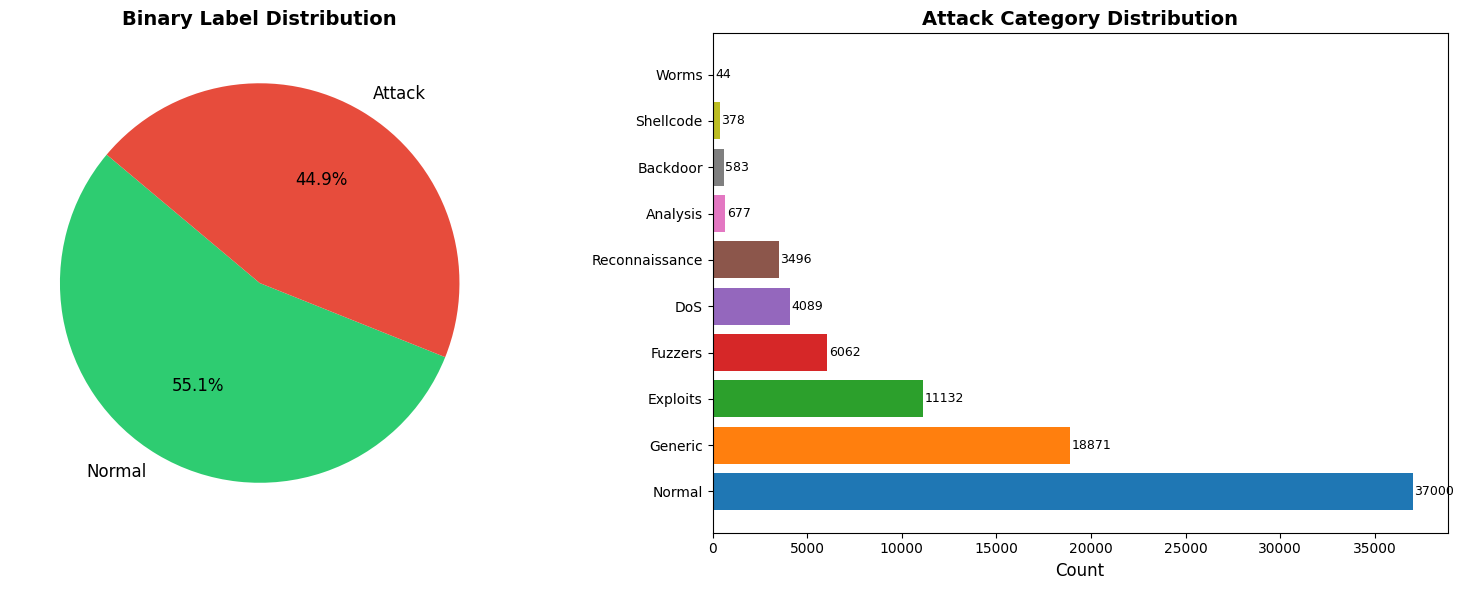

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

label_counts = train_df['label'].value_counts()
axes[0].pie(
    label_counts,
    labels=['Normal', 'Attack'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=140,
    textprops={'fontsize': 12}
)
axes[0].set_title('Binary Label Distribution', fontsize=14, fontweight='bold')

attack_counts = train_df['attack_cat'].value_counts()
colors = plt.cm.tab10(np.linspace(0, 1, len(attack_counts)))
bars = axes[1].barh(attack_counts.index, attack_counts.values, color=colors)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_title('Attack Category Distribution', fontsize=14, fontweight='bold')
for bar, val in zip(bars, attack_counts.values):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Missing Values Analysis

In [10]:
missing_train = train_df.isnull().sum()
missing_test  = test_df.isnull().sum()

missing_summary = pd.DataFrame({
    'Train Missing': missing_train,
    'Train %': (missing_train / len(train_df) * 100).round(2),
    'Test Missing': missing_test,
    'Test %': (missing_test / len(test_df) * 100).round(2)
})

print('Columns with Missing Values:')
print(missing_summary[missing_summary['Train Missing'] > 0])
print(f'\nTotal missing values in training set : {train_df.isnull().sum().sum()}')
print(f'Total missing values in testing set  : {test_df.isnull().sum().sum()}')

Columns with Missing Values:
Empty DataFrame
Columns: [Train Missing, Train %, Test Missing, Test %]
Index: []

Total missing values in training set : 0
Total missing values in testing set  : 0


### Duplicate Records

In [11]:
print(f'Duplicate rows in training set : {train_df.duplicated().sum()}')
print(f'Duplicate rows in testing set  : {test_df.duplicated().sum()}')

Duplicate rows in training set : 0
Duplicate rows in testing set  : 0


### Feature Type Distribution

In [12]:
dtypes_summary = train_df.dtypes.value_counts()
print('Data Type Summary:')
print(dtypes_summary)

categorical_cols = train_df.select_dtypes(include='object').columns.tolist()
numerical_cols   = train_df.select_dtypes(include=[np.number]).columns.tolist()

print(f'\nCategorical columns : {categorical_cols}')
print(f'Numerical columns   : {len(numerical_cols)}')

Data Type Summary:
int64      30
float64    11
object      4
Name: count, dtype: int64

Categorical columns : ['proto', 'service', 'state', 'attack_cat']
Numerical columns   : 41


### Correlation Heatmap (Top Numerical Features)

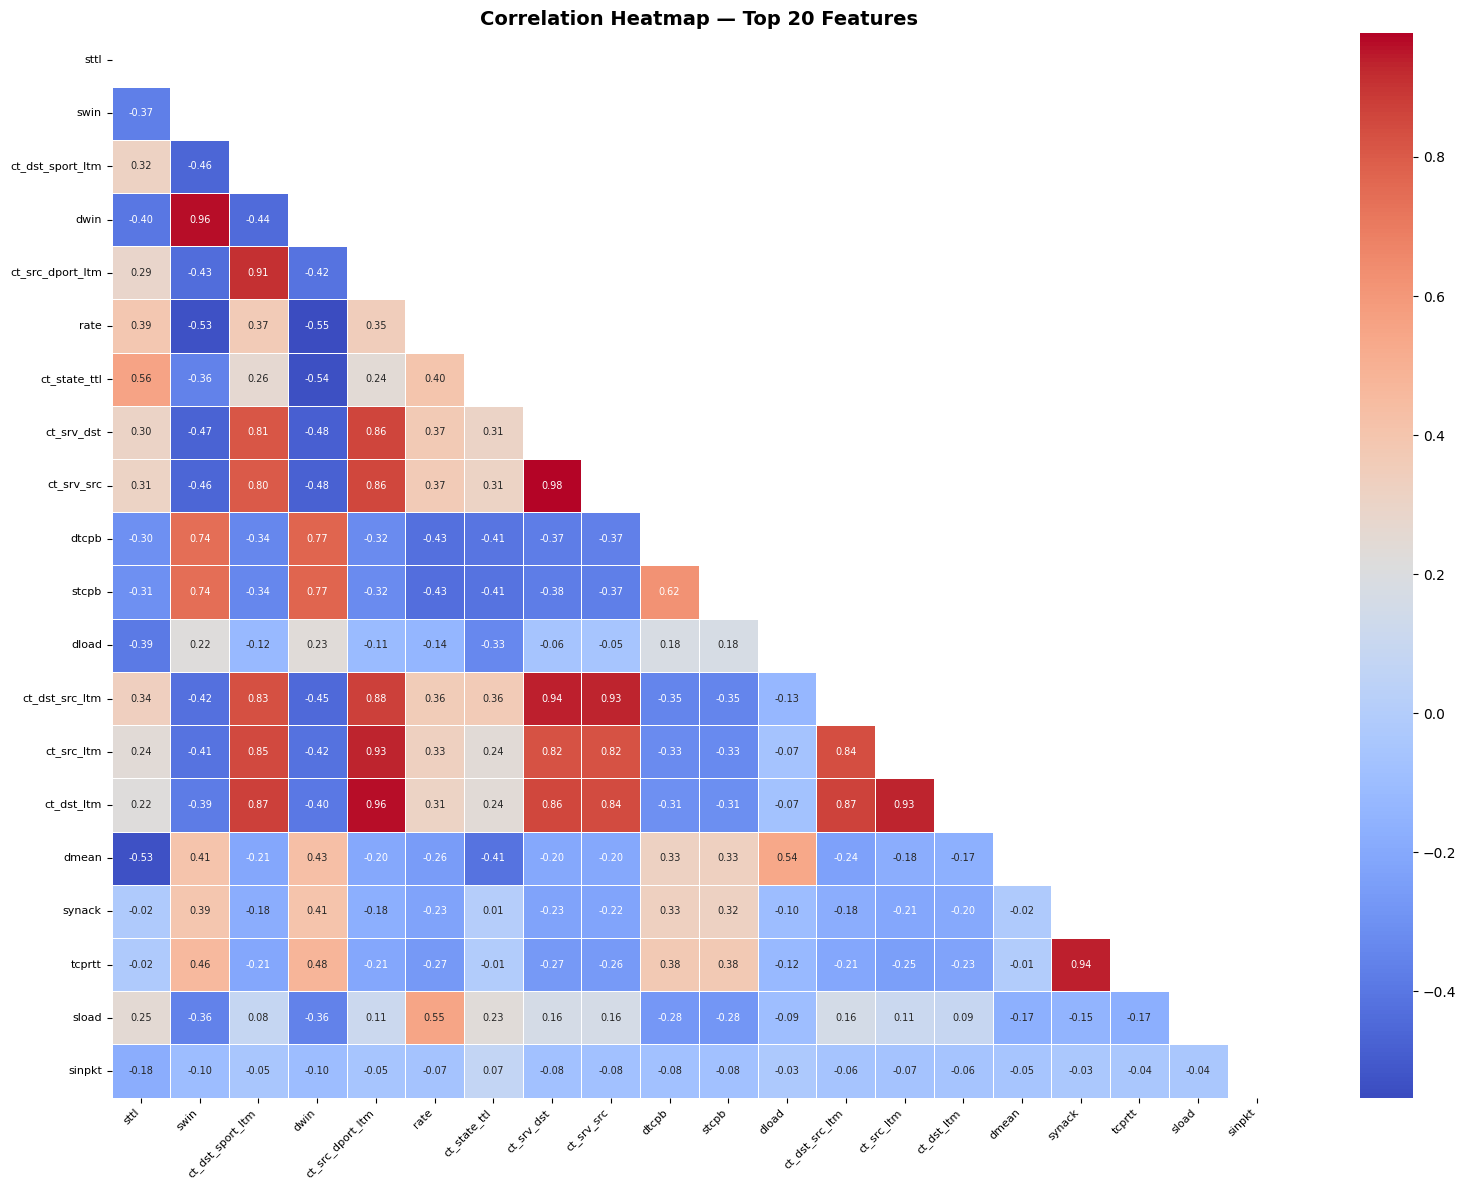

In [13]:
num_df = train_df.select_dtypes(include=[np.number]).drop(columns=['id', 'label'], errors='ignore')
corr_with_label = num_df.corrwith(train_df['label']).abs().sort_values(ascending=False)
top_features = corr_with_label.head(20).index.tolist()

plt.figure(figsize=(16, 12))
corr_matrix = train_df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Heatmap — Top 20 Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribution of Key Numerical Features

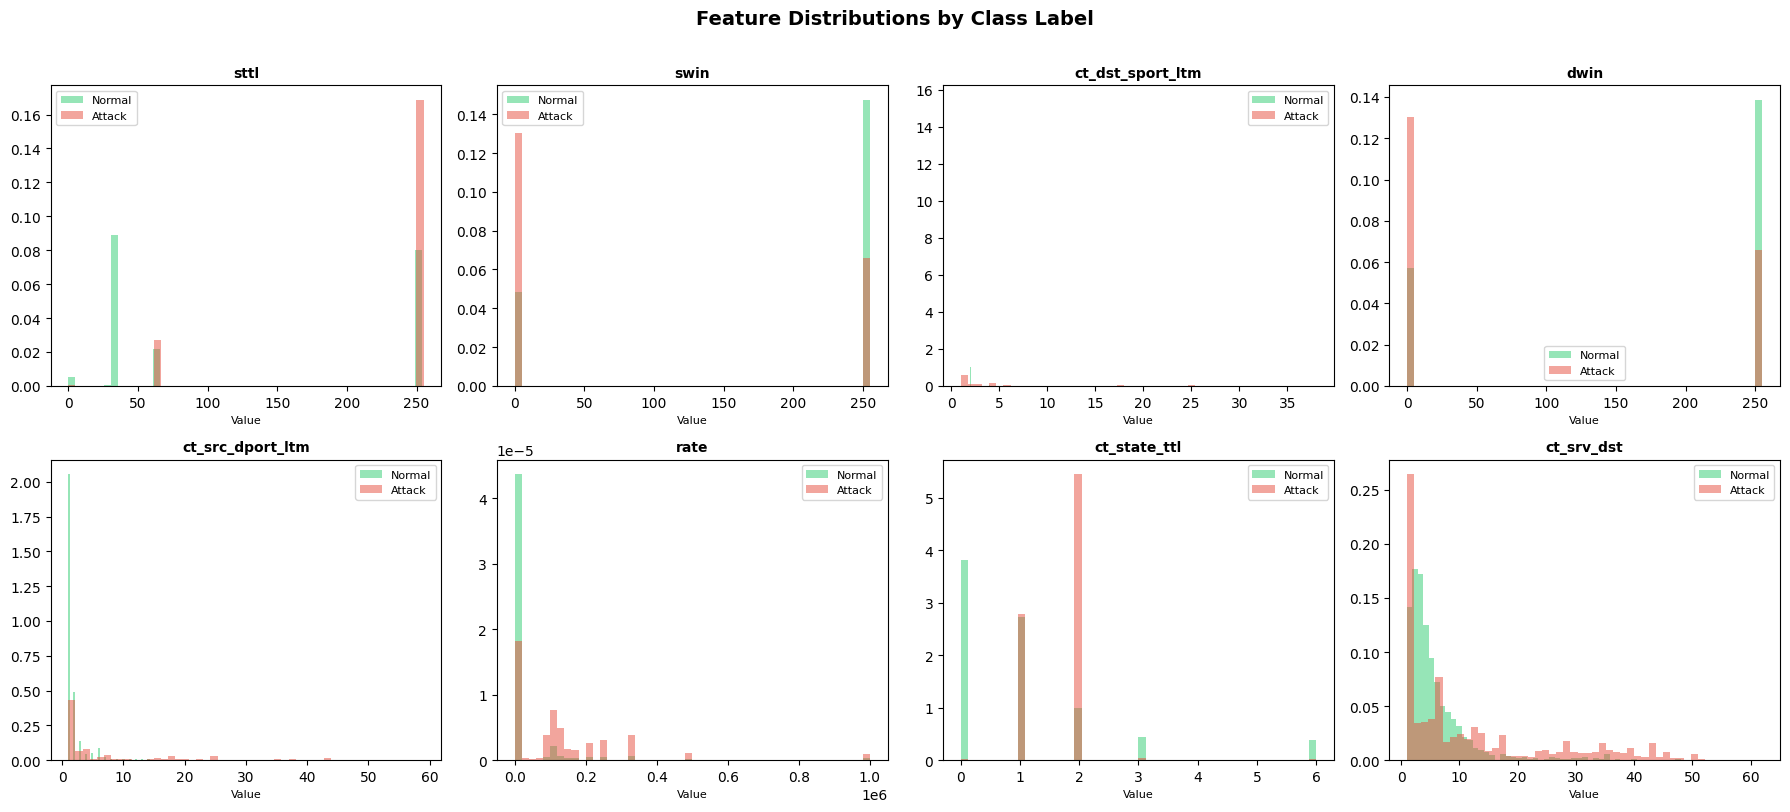

In [14]:
plot_features = corr_with_label.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    for label_val, color, name in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Attack')]:
        subset = train_df[train_df['label'] == label_val][feat].dropna()
        axes[i].hist(subset, bins=50, alpha=0.5, color=color, label=name, density=True)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value', fontsize=8)

plt.suptitle('Feature Distributions by Class Label', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Data Preprocessing

### Combine Train and Test for Consistent Encoding

In [15]:
train_df_proc = train_df.copy()
test_df_proc  = test_df.copy()

DROP_COLS = ['id', 'attack_cat']
train_df_proc.drop(columns=DROP_COLS, errors='ignore', inplace=True)
test_df_proc.drop(columns=DROP_COLS,  errors='ignore', inplace=True)

print(f'Training shape after dropping ID/attack_cat : {train_df_proc.shape}')
print(f'Testing  shape after dropping ID/attack_cat : {test_df_proc.shape}')

Training shape after dropping ID/attack_cat : (82332, 43)
Testing  shape after dropping ID/attack_cat : (175341, 43)


### Handle Missing Values

In [16]:
for col in train_df_proc.select_dtypes(include=[np.number]).columns:
    median_val = train_df_proc[col].median()
    train_df_proc[col].fillna(median_val, inplace=True)
    test_df_proc[col].fillna(median_val,  inplace=True)

for col in train_df_proc.select_dtypes(include='object').columns:
    mode_val = train_df_proc[col].mode()[0]
    train_df_proc[col].fillna(mode_val, inplace=True)
    test_df_proc[col].fillna(mode_val,  inplace=True)

print('Missing values after imputation:')
print(f'  Train : {train_df_proc.isnull().sum().sum()}')
print(f'  Test  : {test_df_proc.isnull().sum().sum()}')

Missing values after imputation:
  Train : 0
  Test  : 0


### Remove Duplicate Rows

In [17]:
before = len(train_df_proc)
train_df_proc.drop_duplicates(inplace=True)
print(f'Rows removed from training set : {before - len(train_df_proc)}')
print(f'Training set size after dedup  : {len(train_df_proc)}')

Rows removed from training set : 28380
Training set size after dedup  : 53952


### Encode Categorical Variables

In [18]:
cat_cols = train_df_proc.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode : {cat_cols}')

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df_proc[col], test_df_proc[col]], axis=0).astype(str)
    le.fit(combined)
    train_df_proc[col] = le.transform(train_df_proc[col].astype(str))
    test_df_proc[col]  = le.transform(test_df_proc[col].astype(str))
    le_dict[col] = le

print('Encoding complete.')

Categorical columns to encode : ['proto', 'service', 'state']
Encoding complete.


### Separate Features and Target

In [19]:
X_train = train_df_proc.drop(columns=['label'])
y_train = train_df_proc['label']

X_test  = test_df_proc.drop(columns=['label'])
y_test  = test_df_proc['label']

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print(f'\nClass balance in y_train :')
print(y_train.value_counts())

X_train : (53952, 42)  |  y_train : (53952,)
X_test  : (175341, 42)   |  y_test  : (175341,)

Class balance in y_train :
label
0    34206
1    19746
Name: count, dtype: int64


### Feature Scaling

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print('Feature scaling complete (StandardScaler).')

Feature scaling complete (StandardScaler).


## Feature Selection

### Mutual Information Feature Ranking

In [21]:
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print('Top 20 Features by Mutual Information:')
print(mi_series.head(20))

Top 20 Features by Mutual Information:
sbytes         0.3473
dbytes         0.2496
smean          0.2324
ct_state_ttl   0.2150
dmean          0.1922
sttl           0.1887
tcprtt         0.1865
synack         0.1857
dttl           0.1837
dinpkt         0.1680
sload          0.1675
rate           0.1610
ackdat         0.1566
dur            0.1466
dpkts          0.1356
dload          0.1249
sinpkt         0.1146
ct_srv_dst     0.1118
djit           0.1043
sjit           0.0973
dtype: float64


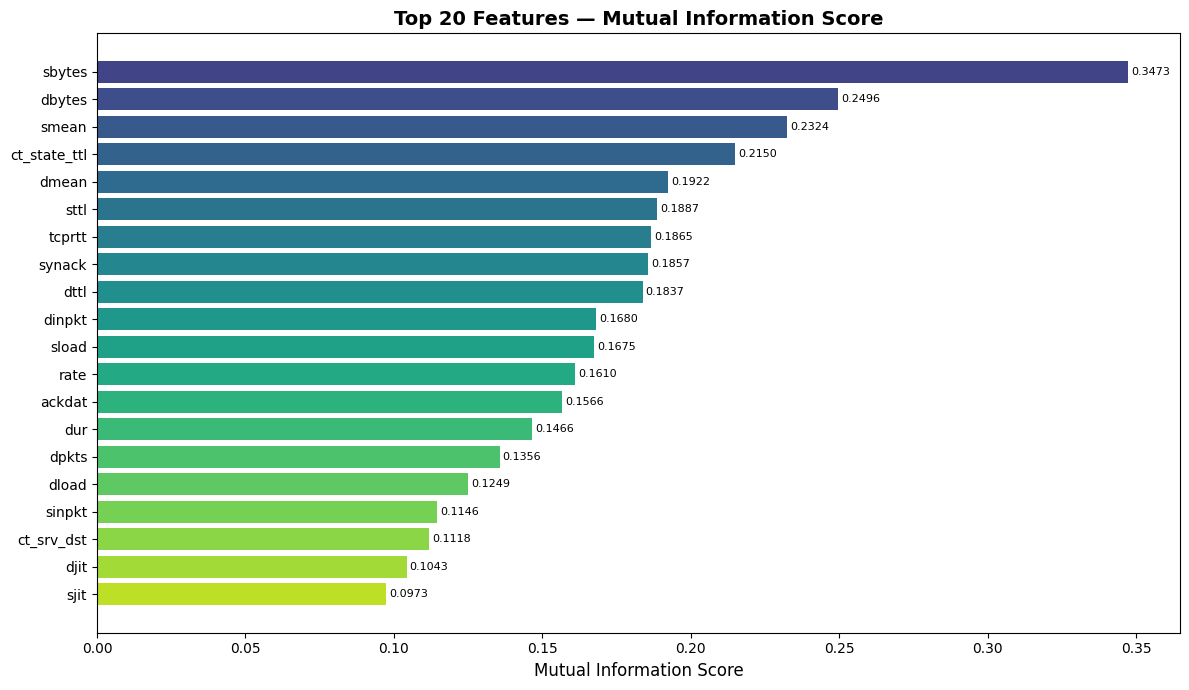

In [22]:
plt.figure(figsize=(12, 7))
top20_mi = mi_series.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top20_mi)))
bars = plt.barh(top20_mi.index[::-1], top20_mi.values[::-1], color=colors[::-1])
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title('Top 20 Features — Mutual Information Score', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top20_mi.values[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

### Select Top Features

In [23]:
TOP_K = 30
selected_features = mi_series.head(TOP_K).index.tolist()

X_train_sel = X_train_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]

print(f'Selected {TOP_K} features for modelling.')
print(f'X_train_sel shape : {X_train_sel.shape}')
print(f'X_test_sel  shape : {X_test_sel.shape}')

Selected 30 features for modelling.
X_train_sel shape : (53952, 30)
X_test_sel  shape : (175341, 30)


## Handle Class Imbalance with SMOTE

In [24]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_res).value_counts())

Before SMOTE:
label
0    34206
1    19746
Name: count, dtype: int64

After SMOTE:
label
0    34206
1    34206
Name: count, dtype: int64


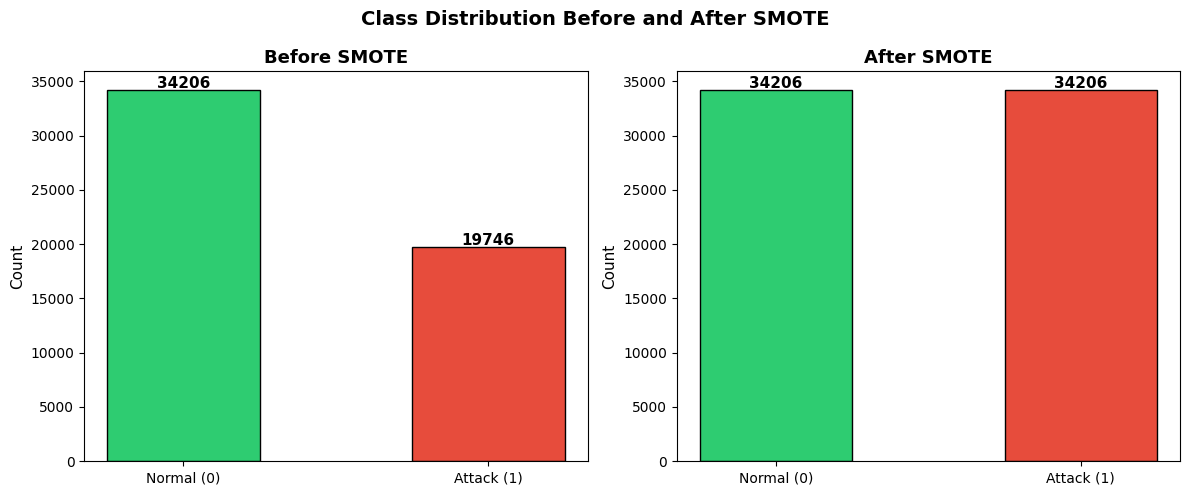

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, counts, title in [
    (axes[0], y_train.value_counts(), 'Before SMOTE'),
    (axes[1], pd.Series(y_train_res).value_counts(), 'After SMOTE')
]:
    bars = ax.bar(['Normal (0)', 'Attack (1)'], counts.sort_index().values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count', fontsize=11)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                str(bar.get_height()), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution Before and After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Machine Learning Models — Training and Evaluation

### Helper Functions

In [26]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    result = {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    }
    return result, model, y_pred, y_prob


def plot_confusion_matrix(y_te, y_pred, model_name):
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


results_list  = []
trained_models = {}
predictions    = {}

### Model 1 — Logistic Regression

In [27]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs', C=1.0)

lr_result, lr_fitted, lr_pred, lr_prob = evaluate_model(
    'Logistic Regression', lr_model, X_train_res, y_train_res, X_test_sel, y_test
)

results_list.append(lr_result)
trained_models['Logistic Regression'] = lr_fitted
predictions['Logistic Regression']    = (lr_pred, lr_prob)

print(f"Logistic Regression — Accuracy: {lr_result['Accuracy']:.4f}  |  F1: {lr_result['F1-Score']:.4f}  |  AUC: {lr_result['AUC-ROC']:.4f}")
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Normal', 'Attack']))

Logistic Regression — Accuracy: 0.8133  |  F1: 0.8504  |  AUC: 0.9342

Classification Report:
              precision    recall  f1-score   support

      Normal       0.65      0.89      0.75     56000
      Attack       0.94      0.78      0.85    119341

    accuracy                           0.81    175341
   macro avg       0.79      0.83      0.80    175341
weighted avg       0.85      0.81      0.82    175341



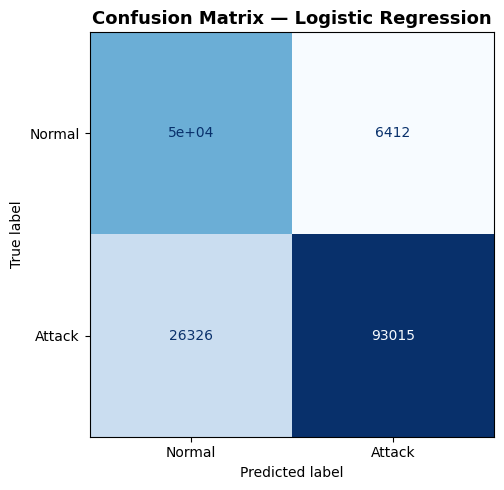

In [28]:
plot_confusion_matrix(y_test, lr_pred, 'Logistic Regression')

### Model 2 — Random Forest

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_result, rf_fitted, rf_pred, rf_prob = evaluate_model(
    'Random Forest', rf_model, X_train_res, y_train_res, X_test_sel, y_test
)

results_list.append(rf_result)
trained_models['Random Forest'] = rf_fitted
predictions['Random Forest']    = (rf_pred, rf_prob)

print(f"Random Forest — Accuracy: {rf_result['Accuracy']:.4f}  |  F1: {rf_result['F1-Score']:.4f}  |  AUC: {rf_result['AUC-ROC']:.4f}")
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Attack']))

Random Forest — Accuracy: 0.9013  |  F1: 0.9226  |  AUC: 0.9847

Classification Report:
              precision    recall  f1-score   support

      Normal       0.77      0.98      0.86     56000
      Attack       0.99      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341



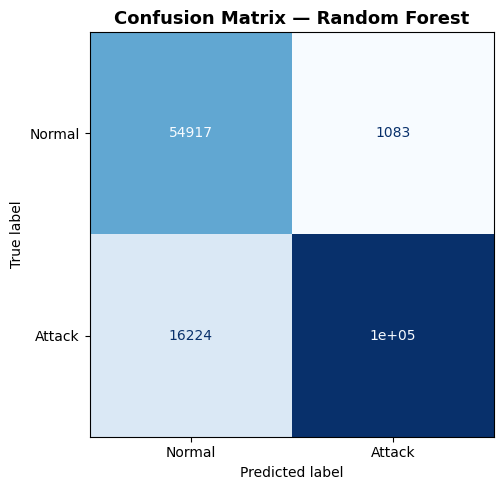

In [30]:
plot_confusion_matrix(y_test, rf_pred, 'Random Forest')

### Model 3 — Support Vector Machine (SVM)

In [31]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=RANDOM_STATE
)

svm_result, svm_fitted, svm_pred, svm_prob = evaluate_model(
    'SVM', svm_model, X_train_res, y_train_res, X_test_sel, y_test
)

results_list.append(svm_result)
trained_models['SVM'] = svm_fitted
predictions['SVM']    = (svm_pred, svm_prob)

print(f"SVM — Accuracy: {svm_result['Accuracy']:.4f}  |  F1: {svm_result['F1-Score']:.4f}  |  AUC: {svm_result['AUC-ROC']:.4f}")
print('\nClassification Report:')
print(classification_report(y_test, svm_pred, target_names=['Normal', 'Attack']))

SVM — Accuracy: 0.8500  |  F1: 0.8798  |  AUC: 0.9492

Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.94      0.80     56000
      Attack       0.97      0.81      0.88    119341

    accuracy                           0.85    175341
   macro avg       0.83      0.87      0.84    175341
weighted avg       0.88      0.85      0.85    175341



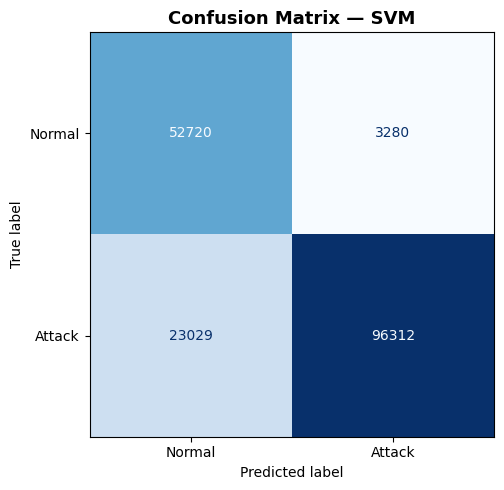

In [32]:
plot_confusion_matrix(y_test, svm_pred, 'SVM')

### Model 4 — XGBoost

In [33]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_result, xgb_fitted, xgb_pred, xgb_prob = evaluate_model(
    'XGBoost', xgb_model, X_train_res, y_train_res, X_test_sel, y_test
)

results_list.append(xgb_result)
trained_models['XGBoost'] = xgb_fitted
predictions['XGBoost']    = (xgb_pred, xgb_prob)

print(f"XGBoost — Accuracy: {xgb_result['Accuracy']:.4f}  |  F1: {xgb_result['F1-Score']:.4f}  |  AUC: {xgb_result['AUC-ROC']:.4f}")
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['Normal', 'Attack']))

XGBoost — Accuracy: 0.8948  |  F1: 0.9172  |  AUC: 0.9844

Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.98      0.86     56000
      Attack       0.99      0.86      0.92    119341

    accuracy                           0.89    175341
   macro avg       0.87      0.92      0.89    175341
weighted avg       0.92      0.89      0.90    175341



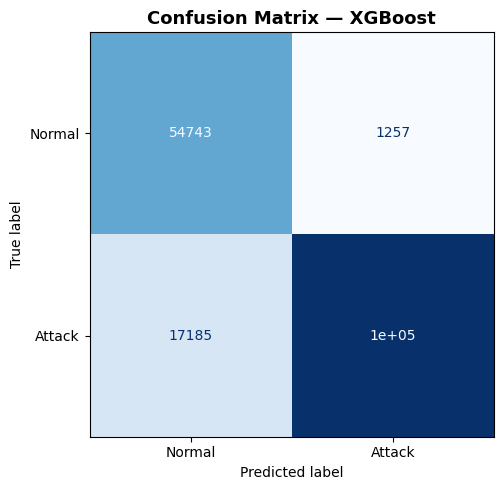

In [34]:
plot_confusion_matrix(y_test, xgb_pred, 'XGBoost')

## Model Performance Comparison

### Summary Table

In [35]:
results_df = pd.DataFrame(results_list)
results_df = results_df.set_index('Model')
results_df = results_df.sort_values('F1-Score', ascending=False)
results_df.style.background_gradient(cmap='YlGn').format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Random Forest,0.9013,0.9896,0.8641,0.9226,0.9847
XGBoost,0.8948,0.9878,0.8560,0.9172,0.9844
SVM,0.8500,0.9671,0.8070,0.8798,0.9492
Logistic Regression,0.8133,0.9355,0.7794,0.8504,0.9342


### Grouped Bar Chart

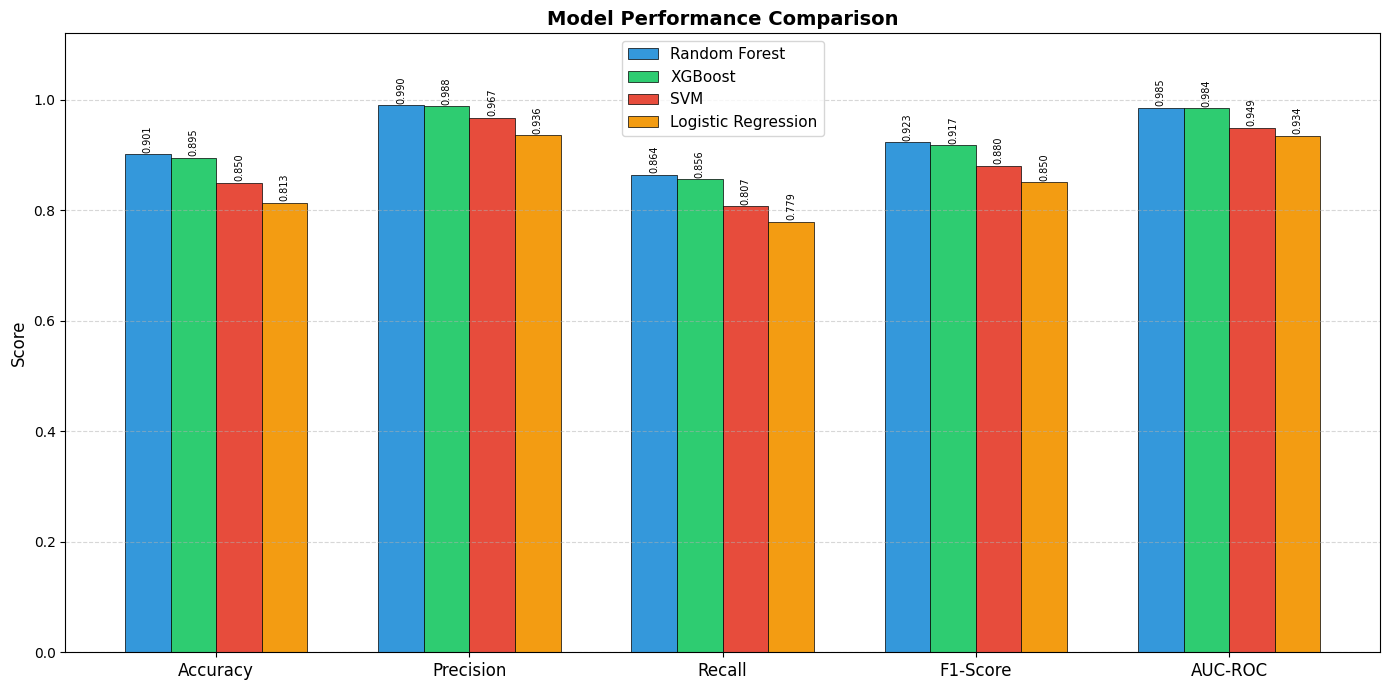

In [36]:
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
models   = results_df.index.tolist()
x        = np.arange(len(metrics))
width    = 0.18
colors   = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 7))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [results_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, edgecolor='black', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### ROC Curves — All Models

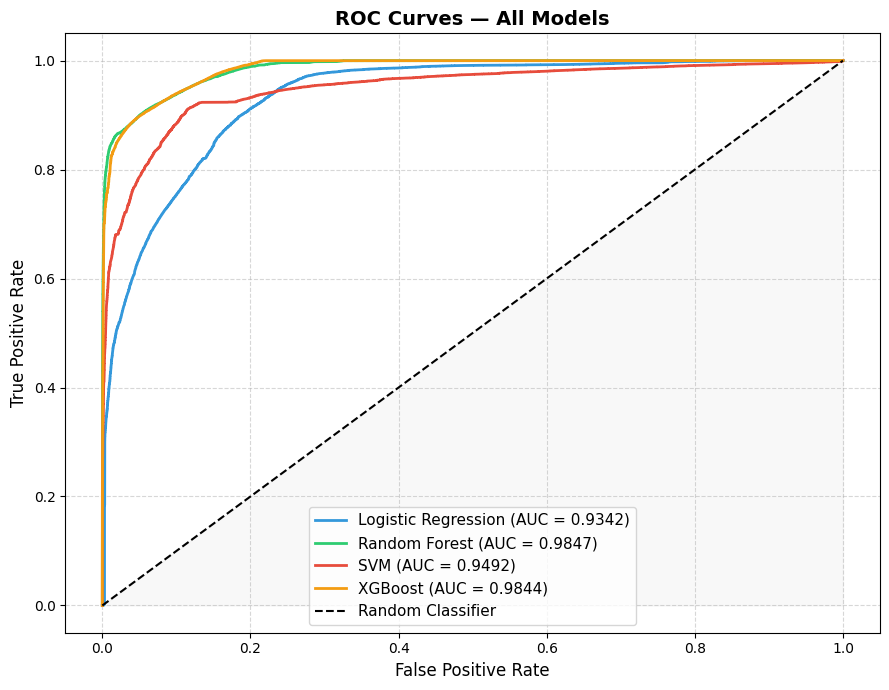

In [37]:
plt.figure(figsize=(9, 7))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for (model_name, (_, y_prob)), color in zip(predictions.items(), colors):
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, lw=2, color=color, label=f'{model_name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance Analysis

### Random Forest Feature Importance

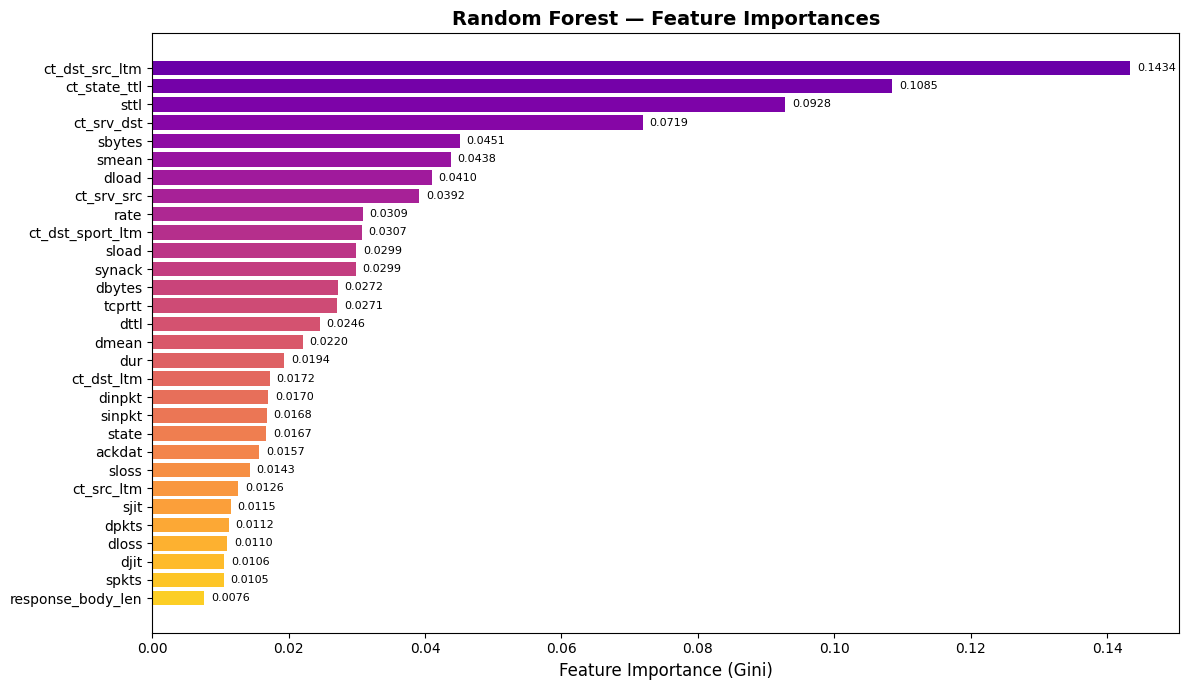

In [38]:
rf_importances = pd.Series(
    rf_fitted.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(rf_importances)))
bars = plt.barh(rf_importances.index[::-1], rf_importances.values[::-1], color=colors[::-1])
plt.xlabel('Feature Importance (Gini)', fontsize=12)
plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
for bar, val in zip(bars, rf_importances.values[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### XGBoost Feature Importance

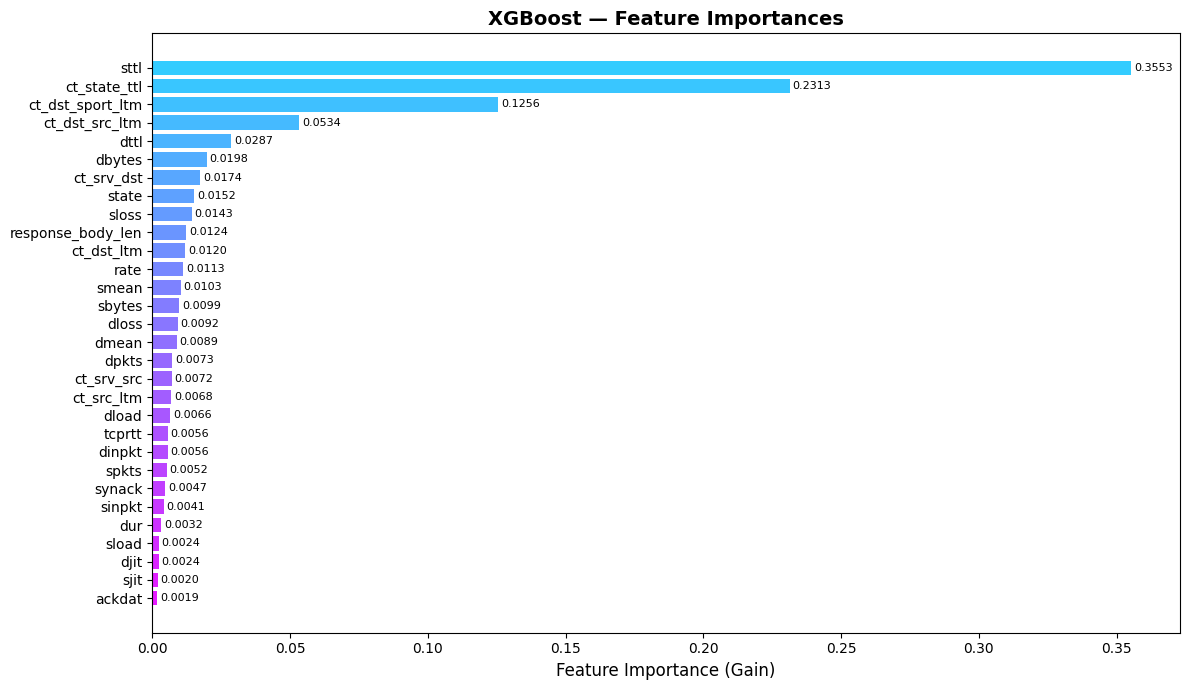

In [39]:
xgb_importances = pd.Series(
    xgb_fitted.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
colors = plt.cm.cool(np.linspace(0.2, 0.9, len(xgb_importances)))
bars = plt.barh(xgb_importances.index[::-1], xgb_importances.values[::-1], color=colors[::-1])
plt.xlabel('Feature Importance (Gain)', fontsize=12)
plt.title('XGBoost — Feature Importances', fontsize=14, fontweight='bold')
for bar, val in zip(bars, xgb_importances.values[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP Values — XGBoost Interpretability

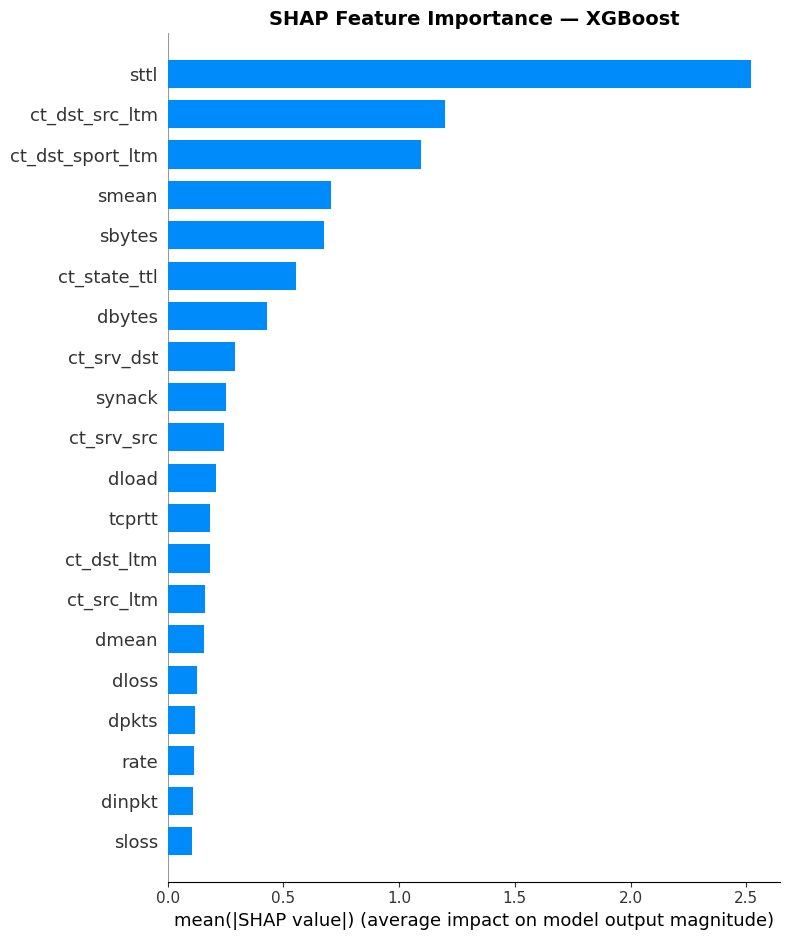

In [40]:
explainer   = shap.TreeExplainer(xgb_fitted)
shap_sample = X_test_sel.sample(n=min(1000, len(X_test_sel)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False, max_display=20)
plt.title('SHAP Feature Importance — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

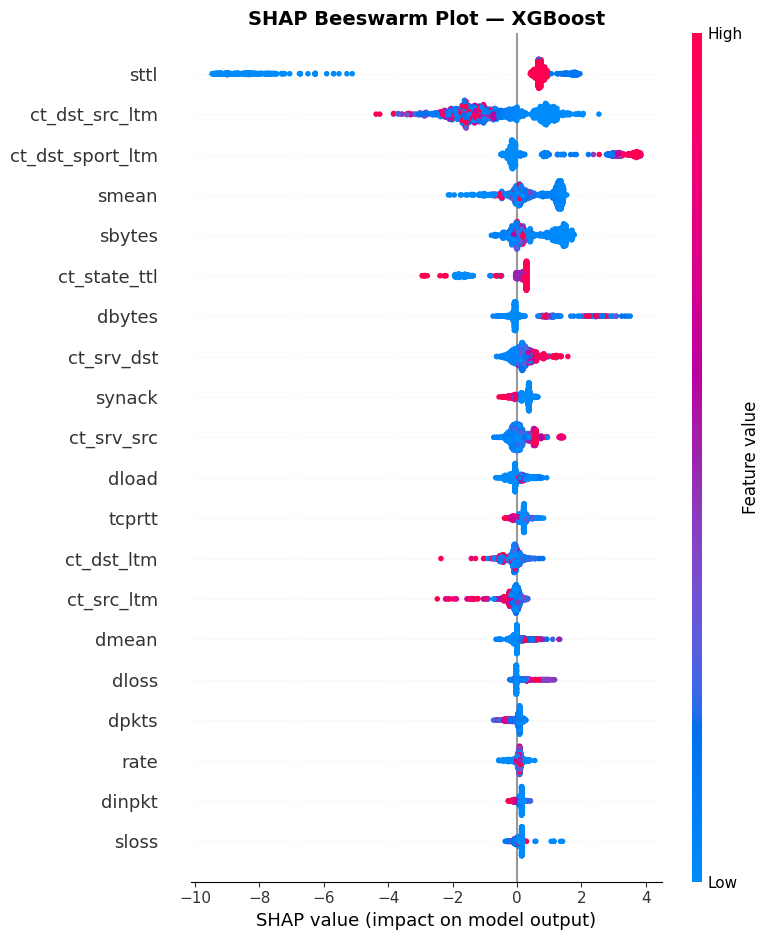

In [41]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, show=False, max_display=20)
plt.title('SHAP Beeswarm Plot — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-Validation Analysis

In [42]:
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, use_label_encoder=False,
                                         eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_res, y_train_res,
                             cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} | F1 per fold: {[f"{s:.4f}" for s in scores]}  |  Mean: {scores.mean():.4f}  |  Std: {scores.std():.4f}')

Logistic Regression       | F1 per fold: ['0.8205', '0.8147', '0.8249', '0.8169', '0.8234']  |  Mean: 0.8201  |  Std: 0.0038
Random Forest             | F1 per fold: ['0.9692', '0.9710', '0.9710', '0.9695', '0.9702']  |  Mean: 0.9702  |  Std: 0.0007
XGBoost                   | F1 per fold: ['0.9735', '0.9727', '0.9722', '0.9726', '0.9727']  |  Mean: 0.9727  |  Std: 0.0004


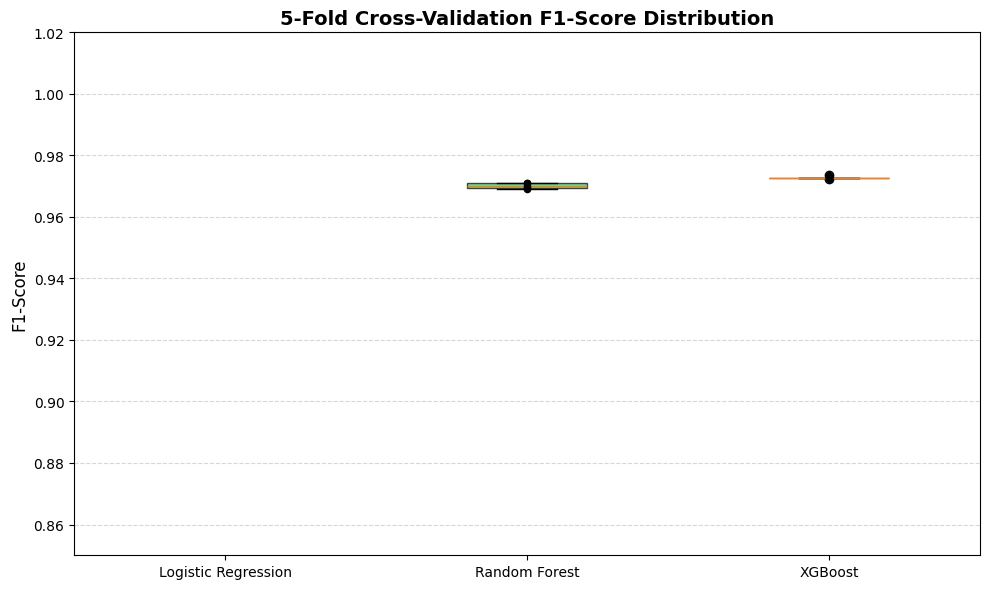

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

cv_df = pd.DataFrame(cv_results)
bp = ax.boxplot(
    [cv_df[col] for col in cv_df.columns],
    labels=cv_df.columns,
    patch_artist=True,
    notch=False,
    widths=0.4
)
colors_box = ['#3498db', '#2ecc71', '#f39c12']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, col in enumerate(cv_df.columns, 1):
    ax.scatter([i] * len(cv_df[col]), cv_df[col], color='black', zorder=3, s=20)

ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation F1-Score Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0.85, 1.02)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Attack Category Analysis

In [44]:
test_with_cat = test_df[['attack_cat', 'label']].copy()
test_with_cat['xgb_pred'] = xgb_pred

attack_perf = []
for cat in test_with_cat['attack_cat'].unique():
    subset = test_with_cat[test_with_cat['attack_cat'] == cat]
    if len(subset) < 5:
        continue
    acc = accuracy_score(subset['label'], subset['xgb_pred'])
    rec = recall_score(subset['label'], subset['xgb_pred'], zero_division=0)
    attack_perf.append({'Attack Category': cat, 'Count': len(subset),
                        'Accuracy': acc, 'Recall': rec})

attack_perf_df = pd.DataFrame(attack_perf).sort_values('Recall', ascending=False)
print('XGBoost Performance by Attack Category:')
print(attack_perf_df.to_string(index=False))

XGBoost Performance by Attack Category:
Attack Category  Count  Accuracy  Recall
        Generic  40000    0.9986  0.9986
       Backdoor   1746    0.9708  0.9708
 Reconnaissance  10491    0.9702  0.9702
            DoS  12264    0.9632  0.9632
          Worms    130    0.9538  0.9538
       Exploits  33393    0.9501  0.9501
      Shellcode   1133    0.8773  0.8773
       Analysis   2000    0.7200  0.7200
        Fuzzers  18184    0.2333  0.2333
         Normal  56000    0.9776  0.0000


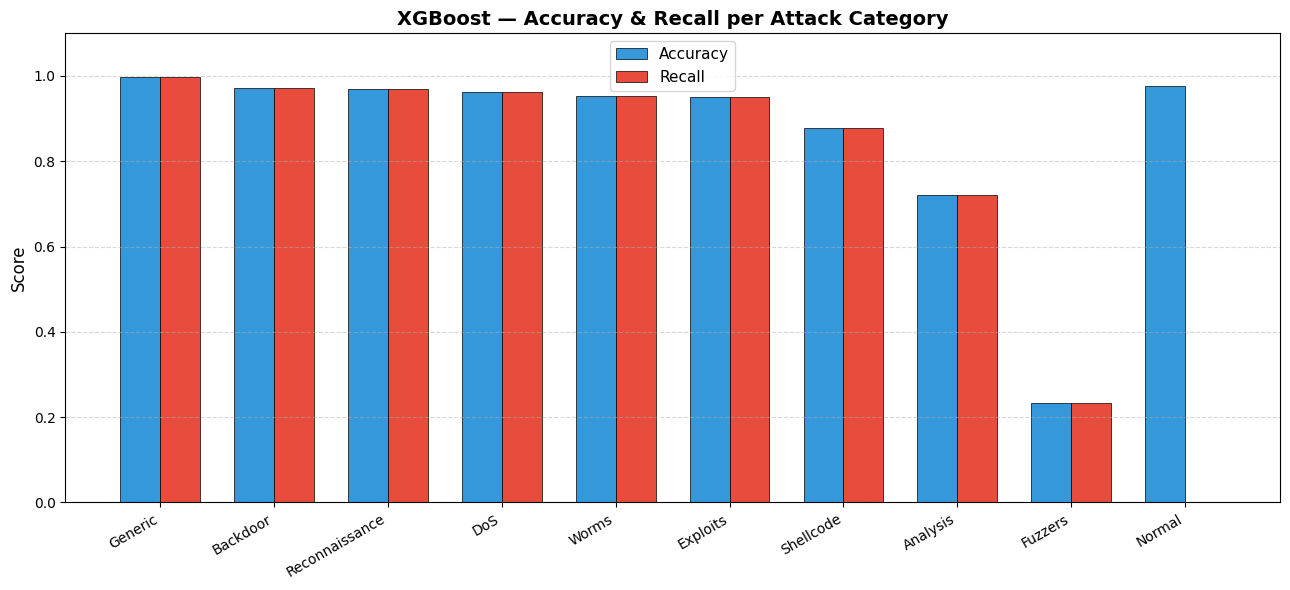

In [45]:
fig, ax = plt.subplots(figsize=(13, 6))
x_cat   = np.arange(len(attack_perf_df))
width   = 0.35

bars1 = ax.bar(x_cat - width/2, attack_perf_df['Accuracy'], width, label='Accuracy',
               color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x_cat + width/2, attack_perf_df['Recall'],   width, label='Recall',
               color='#e74c3c', edgecolor='black', linewidth=0.5)

ax.set_xticks(x_cat)
ax.set_xticklabels(attack_perf_df['Attack Category'], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('XGBoost — Accuracy & Recall per Attack Category', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('attack_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Security Awareness Assessment

### Survey Design and Simulated Responses

In [46]:
np.random.seed(RANDOM_STATE)
N_RESPONDENTS = 200

survey_data = pd.DataFrame({
    'Respondent_ID': range(1, N_RESPONDENTS + 1),

    'Role': np.random.choice(
        ['Student', 'IT Professional', 'Non-IT Employee', 'Manager', 'Academic'],
        N_RESPONDENTS, p=[0.30, 0.20, 0.25, 0.15, 0.10]
    ),

    'Q1_Phishing_Identify': np.random.choice(
        ['Correctly Identified', 'Unsure', 'Missed'],
        N_RESPONDENTS, p=[0.45, 0.30, 0.25]
    ),

    'Q2_Password_Practice': np.random.choice(
        ['Strong Practice', 'Moderate Practice', 'Poor Practice'],
        N_RESPONDENTS, p=[0.35, 0.40, 0.25]
    ),

    'Q3_Public_WiFi': np.random.choice(
        ['Uses VPN / Avoids', 'Sometimes Cautious', 'Uses Freely'],
        N_RESPONDENTS, p=[0.30, 0.35, 0.35]
    ),

    'Q4_Software_Update': np.random.choice(
        ['Updates Promptly', 'Delays Updates', 'Never Updates'],
        N_RESPONDENTS, p=[0.40, 0.35, 0.25]
    ),

    'Q5_2FA_Usage': np.random.choice(
        ['Always Uses 2FA', 'Sometimes', 'Never Uses 2FA'],
        N_RESPONDENTS, p=[0.30, 0.35, 0.35]
    ),

    'Q6_Data_Sharing': np.random.choice(
        ['Very Careful', 'Moderately Careful', 'Not Careful'],
        N_RESPONDENTS, p=[0.40, 0.35, 0.25]
    ),

    'Q7_Incident_Reporting': np.random.choice(
        ['Reports Immediately', 'Unsure How', 'Does Not Report'],
        N_RESPONDENTS, p=[0.35, 0.40, 0.25]
    ),

    'Q8_Training_Received': np.random.choice(
        ['Regular Training', 'Occasional', 'No Training'],
        N_RESPONDENTS, p=[0.30, 0.40, 0.30]
    )
})

print(f'Survey dataset shape : {survey_data.shape}')
survey_data.head(10)

Survey dataset shape : (200, 10)


,Respondent_ID,Role,Q1_Phishing_Identify,Q2_Password_Practice,Q3_Public_WiFi,Q4_Software_Update,Q5_2FA_Usage,Q6_Data_Sharing,Q7_Incident_Reporting,Q8_Training_Received
0,1,IT Professional,Unsure,Strong Practice,Uses VPN / Avoids,Delays Updates,Always Uses 2FA,Not Careful,Reports Immediately,Regular Training
1,2,Academic,Correctly Identified,Poor Practice,Uses VPN / Avoids,Updates Promptly,Sometimes,Very Careful,Reports Immediately,Occasional
2,3,Non-IT Employee,Correctly Identified,Moderate Practice,Uses VPN / Avoids,Delays Updates,Never Uses 2FA,Very Careful,Reports Immediately,Regular Training
3,4,Non-IT Employee,Missed,Poor Practice,Uses VPN / Avoids,Delays Updates,Never Uses 2FA,Very Careful,Unsure How,Occasional
4,5,Student,Unsure,Strong Practice,Uses VPN / Avoids,Delays Updates,Never Uses 2FA,Moderately Careful,Unsure How,Regular Training
5,6,Student,Correctly Identified,Poor Practice,Sometimes Cautious,Delays Updates,Never Uses 2FA,Not Careful,Unsure How,Occasional
6,7,Student,Correctly Identified,Moderate Practice,Uses VPN / Avoids,Never Updates,Never Uses 2FA,Moderately Careful,Does Not Report,Regular Training
7,8,Manager,Unsure,Strong Practice,Sometimes Cautious,Never Updates,Never Uses 2FA,Moderately Careful,Does Not Report,No Training
8,9,Non-IT Employee,Correctly Identified,Poor Practice,Sometimes Cautious,Delays Updates,Always Uses 2FA,Very Careful,Unsure How,Regular Training
9,10,Non-IT Employee,Correctly Identified,Strong Practice,Uses Freely,Updates Promptly,Sometimes,Not Careful,Does Not Report,Occasional


### Compute Awareness Score

In [47]:
score_maps = {
    'Q1_Phishing_Identify':  {'Correctly Identified': 2, 'Unsure': 1, 'Missed': 0},
    'Q2_Password_Practice':  {'Strong Practice': 2,      'Moderate Practice': 1, 'Poor Practice': 0},
    'Q3_Public_WiFi':        {'Uses VPN / Avoids': 2,    'Sometimes Cautious': 1, 'Uses Freely': 0},
    'Q4_Software_Update':    {'Updates Promptly': 2,     'Delays Updates': 1,    'Never Updates': 0},
    'Q5_2FA_Usage':          {'Always Uses 2FA': 2,      'Sometimes': 1,         'Never Uses 2FA': 0},
    'Q6_Data_Sharing':       {'Very Careful': 2,         'Moderately Careful': 1,'Not Careful': 0},
    'Q7_Incident_Reporting': {'Reports Immediately': 2,  'Unsure How': 1,        'Does Not Report': 0},
    'Q8_Training_Received':  {'Regular Training': 2,     'Occasional': 1,        'No Training': 0}
}

for q, mapping in score_maps.items():
    survey_data[f'{q}_score'] = survey_data[q].map(mapping)

score_cols = [f'{q}_score' for q in score_maps]
survey_data['Total_Score'] = survey_data[score_cols].sum(axis=1)
max_score = len(score_maps) * 2
survey_data['Awareness_Pct'] = (survey_data['Total_Score'] / max_score * 100).round(1)

survey_data['Awareness_Level'] = pd.cut(
    survey_data['Awareness_Pct'],
    bins=[0, 40, 60, 80, 100],
    labels=['Low', 'Moderate', 'High', 'Very High'],
    include_lowest=True
)

print('Awareness Score Statistics:')
print(survey_data[['Total_Score', 'Awareness_Pct']].describe().round(2))
print('\nAwareness Level Distribution:')
print(survey_data['Awareness_Level'].value_counts())

Awareness Score Statistics:
       Total_Score  Awareness_Pct
count     200.0000       200.0000
mean        8.5900        53.6900
std         2.2800        14.2400
min         2.0000        12.5000
25%         7.0000        43.8000
50%         8.5000        53.1000
75%        10.0000        62.5000
max        14.0000        87.5000

Awareness Level Distribution:
Awareness_Level
Moderate     98
High         59
Low          35
Very High     8
Name: count, dtype: int64


### Awareness Score Distribution

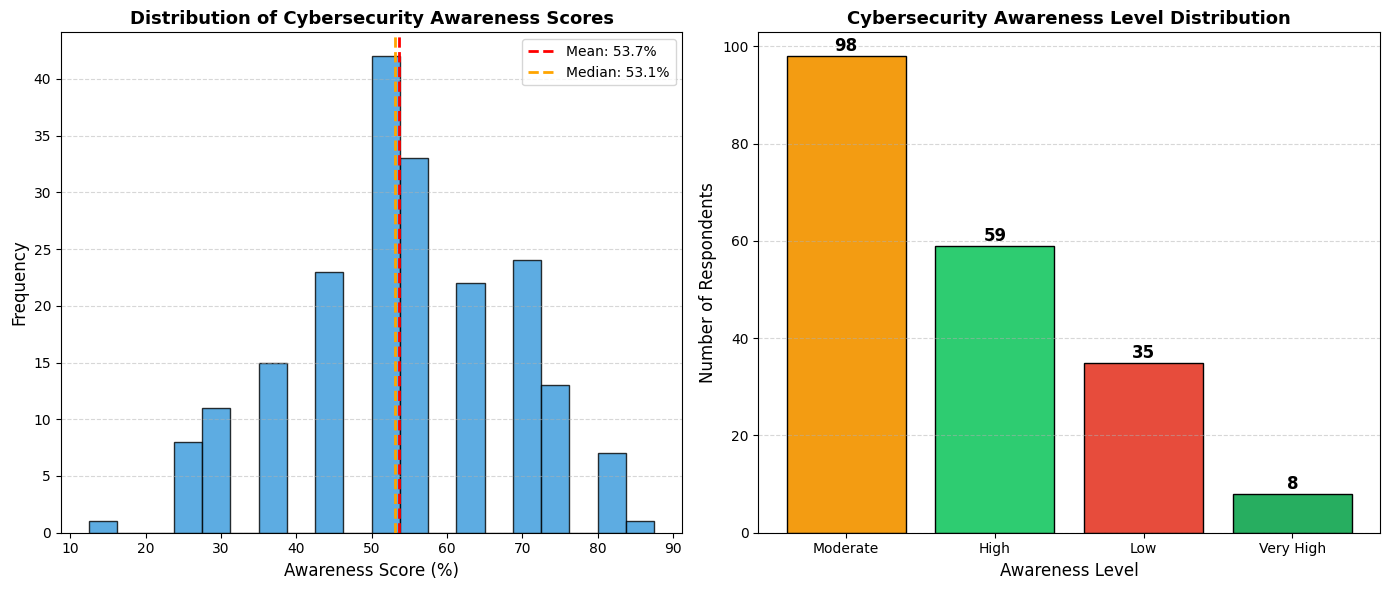

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(survey_data['Awareness_Pct'], bins=20, color='#3498db',
             edgecolor='black', alpha=0.8)
axes[0].axvline(survey_data['Awareness_Pct'].mean(), color='red',
                linestyle='--', lw=2, label=f'Mean: {survey_data["Awareness_Pct"].mean():.1f}%')
axes[0].axvline(survey_data['Awareness_Pct'].median(), color='orange',
                linestyle='--', lw=2, label=f'Median: {survey_data["Awareness_Pct"].median():.1f}%')
axes[0].set_xlabel('Awareness Score (%)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Cybersecurity Awareness Scores', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

level_counts = survey_data['Awareness_Level'].value_counts()
level_colors = {'Low': '#e74c3c', 'Moderate': '#f39c12', 'High': '#2ecc71', 'Very High': '#27ae60'}
bars = axes[1].bar(
    level_counts.index,
    level_counts.values,
    color=[level_colors.get(l, '#3498db') for l in level_counts.index],
    edgecolor='black'
)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(bar.get_height()), ha='center', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Awareness Level', fontsize=12)
axes[1].set_ylabel('Number of Respondents', fontsize=12)
axes[1].set_title('Cybersecurity Awareness Level Distribution', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('awareness_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Awareness by Role

In [49]:
role_awareness = survey_data.groupby('Role')['Awareness_Pct'].agg(['mean', 'median', 'std', 'count'])
role_awareness.columns = ['Mean Score', 'Median Score', 'Std Dev', 'Count']
role_awareness = role_awareness.sort_values('Mean Score', ascending=False)
print('Awareness Score by Role:')
print(role_awareness.round(2))

Awareness Score by Role:
                 Mean Score  Median Score  Std Dev  Count
Role                                                     
IT Professional     57.2900       56.2000  14.9800     36
Non-IT Employee     55.9800       56.2000  15.2500     47
Academic            54.2800       50.0000  13.6700     19
Manager             53.5100       53.1000  12.0800     32
Student             50.0000       50.0000  13.7500     66


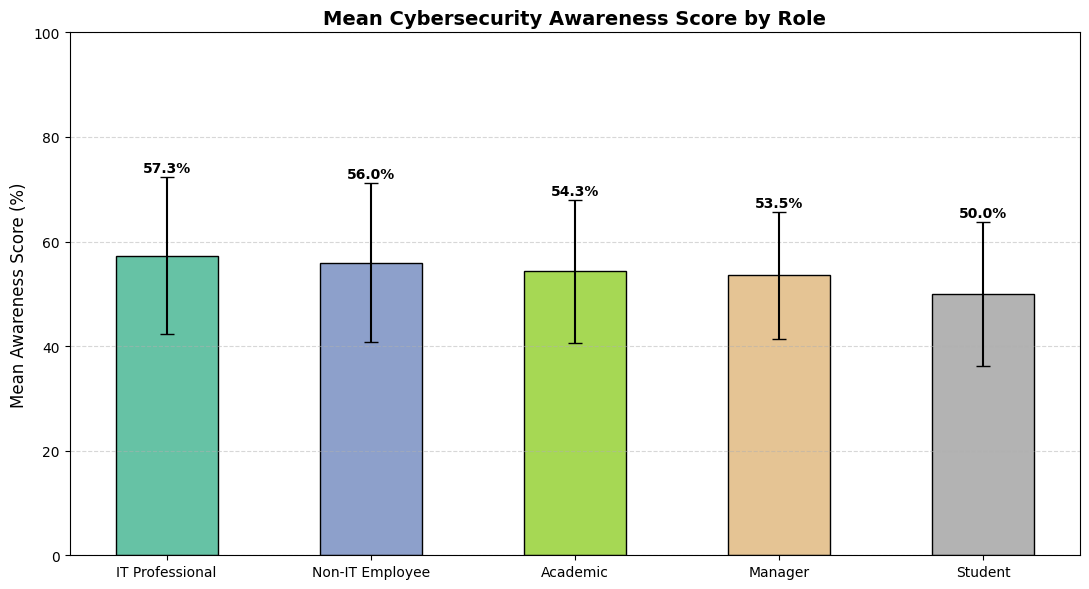

In [50]:
fig, ax = plt.subplots(figsize=(11, 6))
role_colors = plt.cm.Set2(np.linspace(0, 1, len(role_awareness)))
bars = ax.bar(
    role_awareness.index,
    role_awareness['Mean Score'],
    yerr=role_awareness['Std Dev'],
    capsize=5,
    color=role_colors,
    edgecolor='black',
    width=0.5
)
for bar, (_, row) in zip(bars, role_awareness.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + row['Std Dev'] + 1,
            f'{row["Mean Score"]:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Mean Awareness Score (%)', fontsize=12)
ax.set_title('Mean Cybersecurity Awareness Score by Role', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('awareness_by_role.png', dpi=150, bbox_inches='tight')
plt.show()

### Question-Level Response Analysis

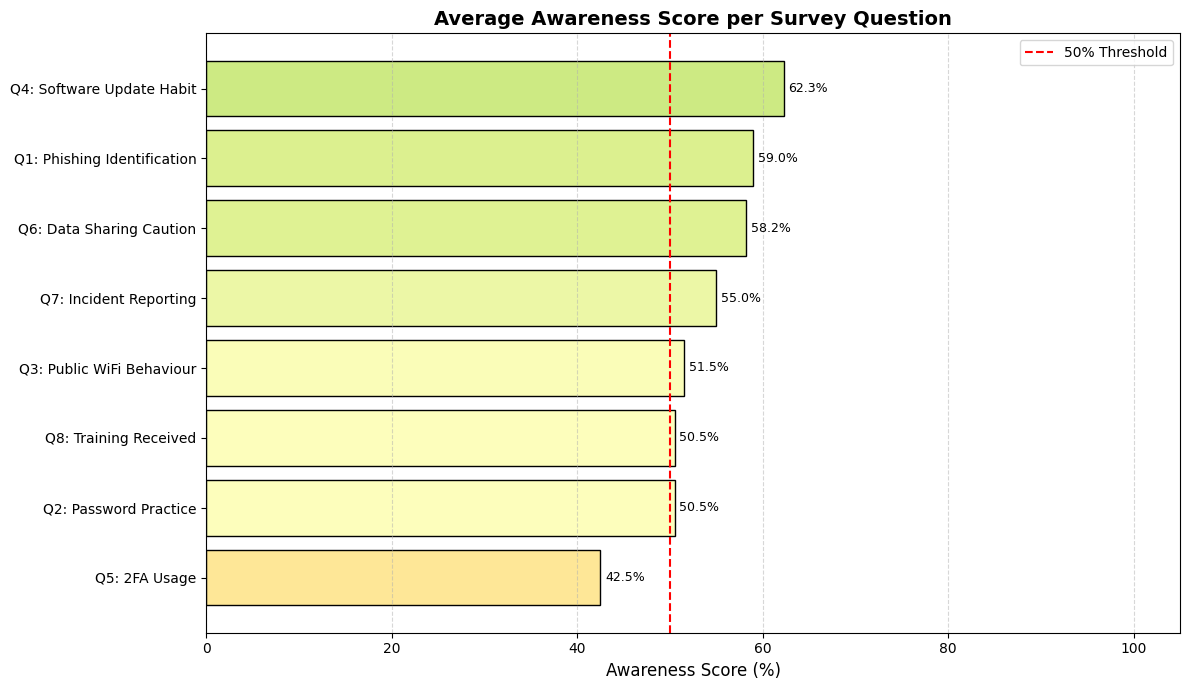

In [51]:
question_labels = {
    'Q1_Phishing_Identify':  'Q1: Phishing Identification',
    'Q2_Password_Practice':  'Q2: Password Practice',
    'Q3_Public_WiFi':        'Q3: Public WiFi Behaviour',
    'Q4_Software_Update':    'Q4: Software Update Habit',
    'Q5_2FA_Usage':          'Q5: 2FA Usage',
    'Q6_Data_Sharing':       'Q6: Data Sharing Caution',
    'Q7_Incident_Reporting': 'Q7: Incident Reporting',
    'Q8_Training_Received':  'Q8: Training Received'
}

mean_scores = {
    q: survey_data[f'{q}_score'].mean() / 2 * 100
    for q in score_maps
}

mean_scores_series = pd.Series(mean_scores, index=score_maps.keys())
mean_scores_series.index = [question_labels[q] for q in mean_scores_series.index]
mean_scores_series = mean_scores_series.sort_values()

plt.figure(figsize=(12, 7))
colors = plt.cm.RdYlGn(mean_scores_series.values / 100)
bars = plt.barh(mean_scores_series.index, mean_scores_series.values, color=colors, edgecolor='black')
plt.axvline(50, color='red', linestyle='--', lw=1.5, label='50% Threshold')
for bar, val in zip(bars, mean_scores_series.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
plt.xlabel('Awareness Score (%)', fontsize=12)
plt.title('Average Awareness Score per Survey Question', fontsize=14, fontweight='bold')
plt.xlim(0, 105)
plt.legend(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('question_scores.png', dpi=150, bbox_inches='tight')
plt.show()

### Stacked Bar Chart — Response Distribution per Question

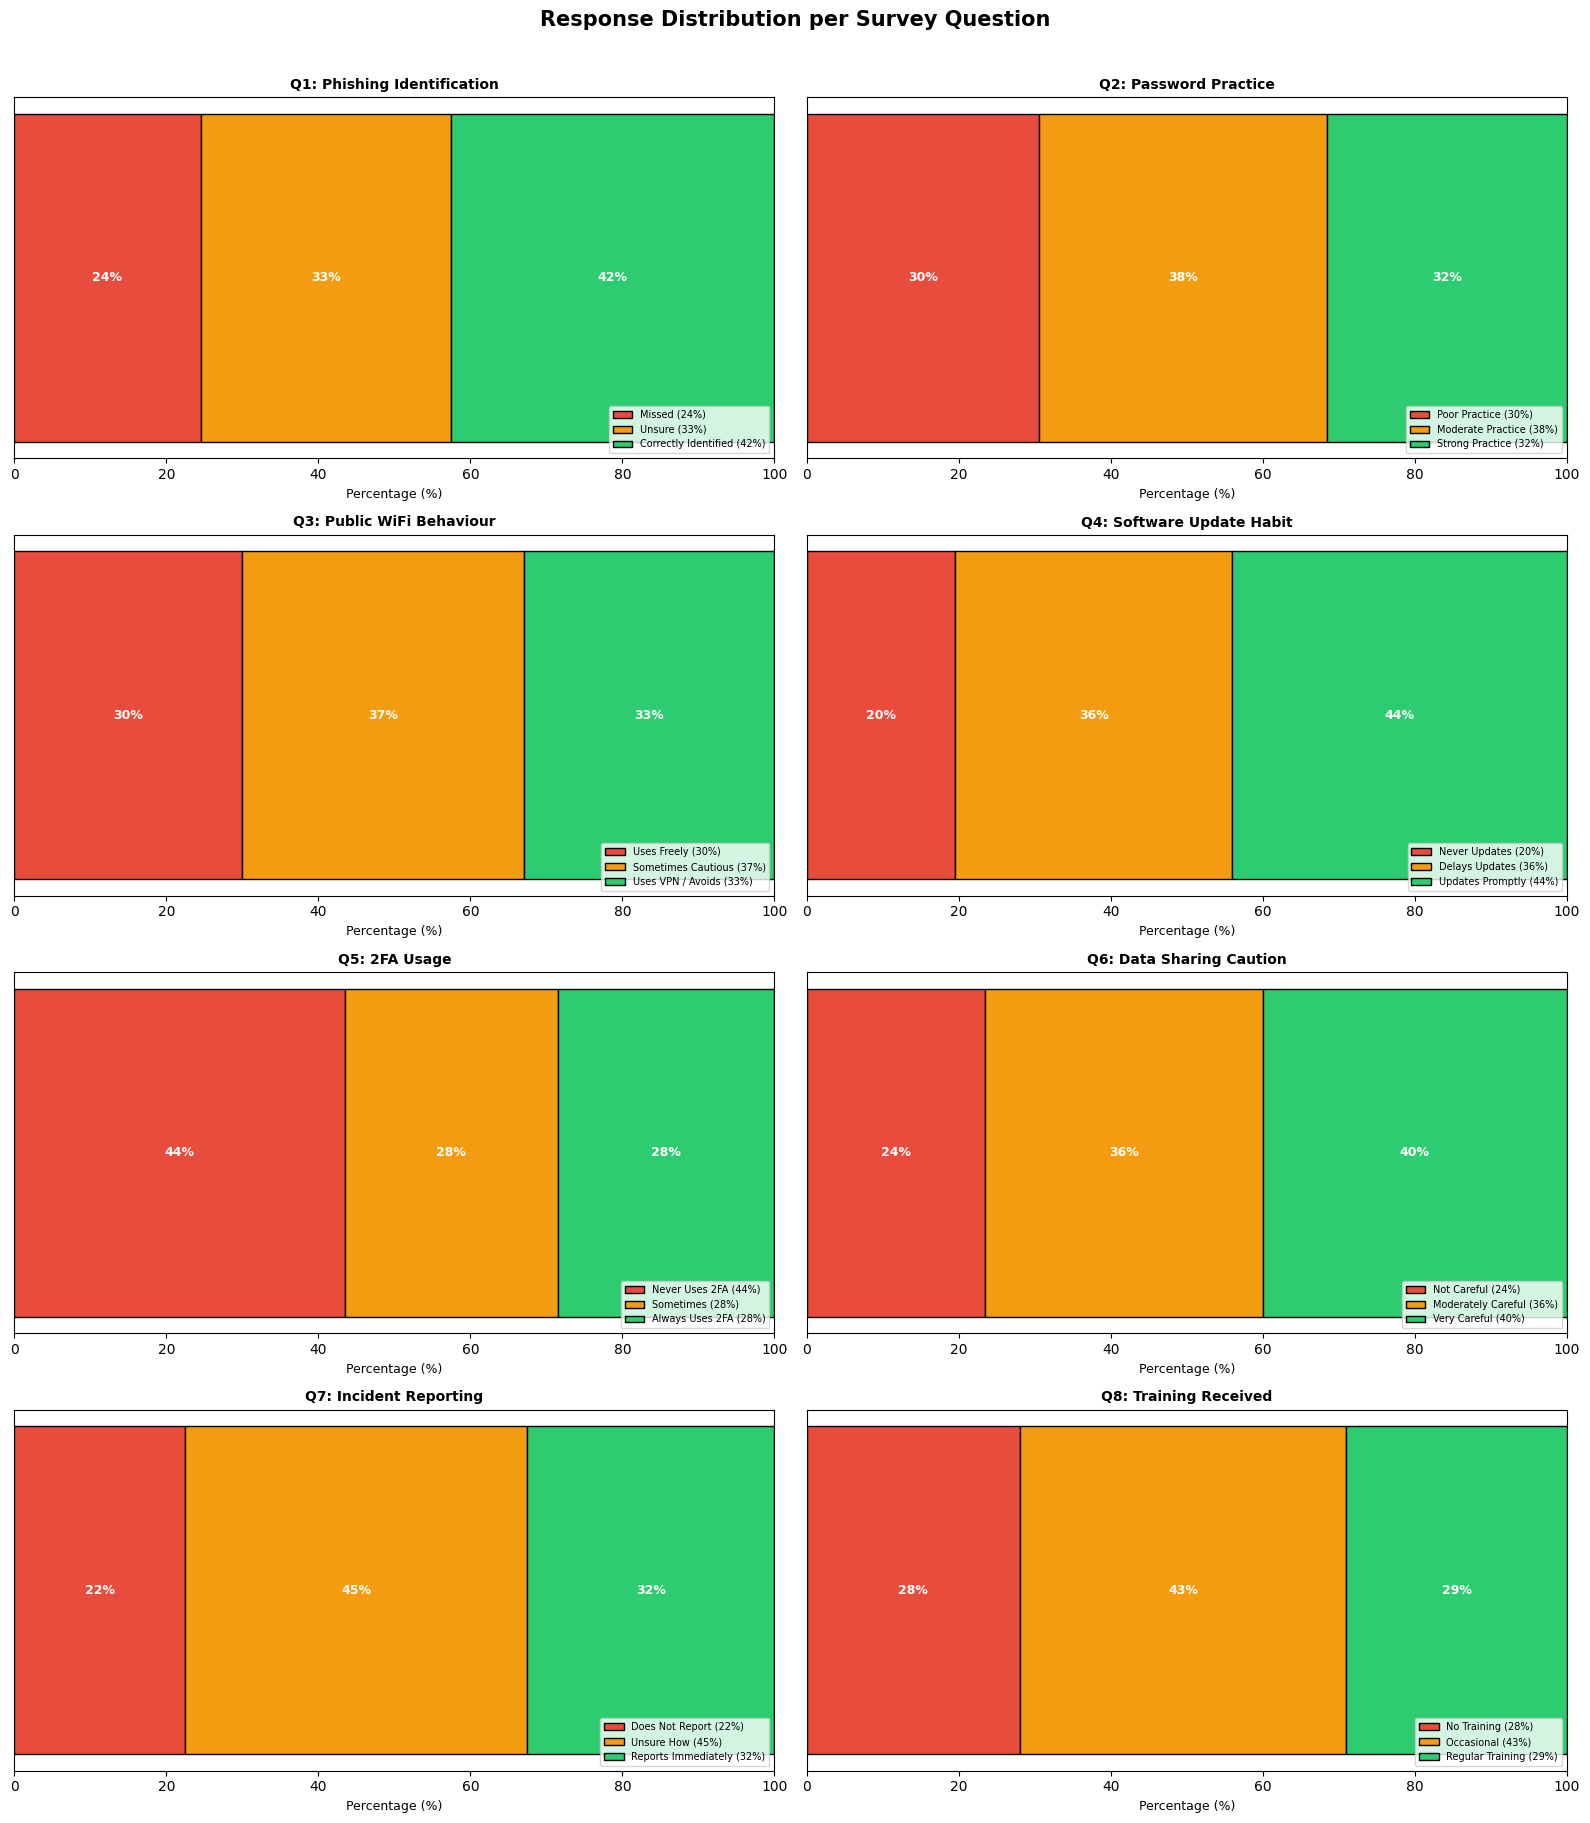

In [52]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

response_colors = {
    0: '#e74c3c',
    1: '#f39c12',
    2: '#2ecc71'
}
score_label_map = {0: 'Low Awareness', 1: 'Moderate Awareness', 2: 'High Awareness'}

for idx, q in enumerate(score_maps.keys()):
    counts = survey_data[q].value_counts()
    score_map_inv = {v: k for k, v in score_maps[q].items()}
    pcts = (counts / len(survey_data) * 100).round(1)

    bottom = 0
    for score_val in sorted(score_maps[q].values()):
        label_text = score_map_inv[score_val]
        pct_val = pcts.get(label_text, 0)
        axes[idx].barh(
            [0], [pct_val], left=[bottom],
            color=response_colors[score_val],
            label=f'{label_text} ({pct_val:.0f}%)',
            height=0.5, edgecolor='black'
        )
        if pct_val > 5:
            axes[idx].text(bottom + pct_val/2, 0, f'{pct_val:.0f}%',
                           ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        bottom += pct_val

    axes[idx].set_xlim(0, 100)
    axes[idx].set_xlabel('Percentage (%)', fontsize=9)
    axes[idx].set_yticks([])
    axes[idx].set_title(question_labels[q], fontsize=10, fontweight='bold')
    axes[idx].legend(fontsize=7, loc='lower right')

plt.suptitle('Response Distribution per Survey Question', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('response_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Combined Analysis — Threat Detection vs Awareness

### Radar Chart — Model Metrics

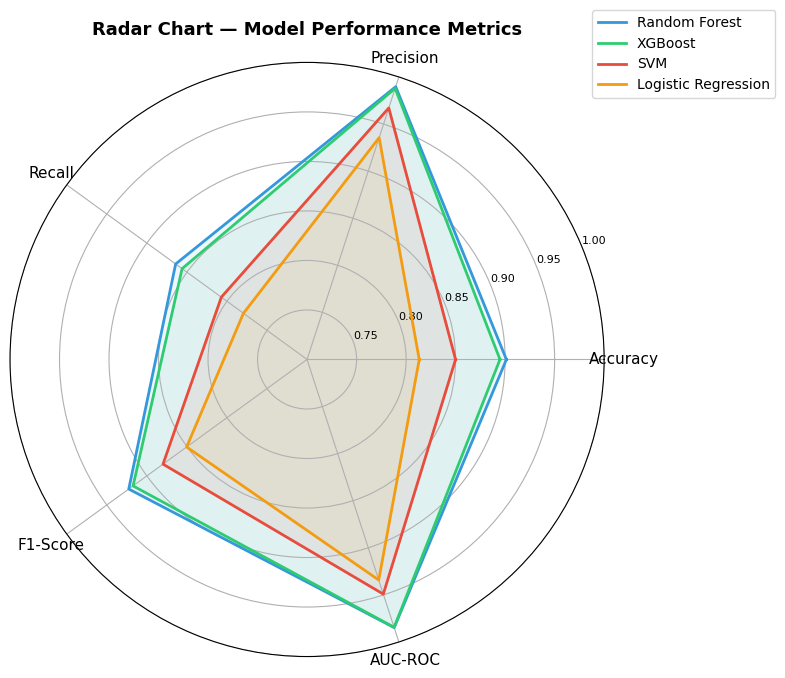

In [53]:
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

radar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for (model_name, row), color in zip(results_df.iterrows(), radar_colors):
    values = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
    ax.plot(angles, values, lw=2, linestyle='solid', label=model_name, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0.7, 1.0)
ax.set_yticks([0.75, 0.80, 0.85, 0.90, 0.95, 1.00])
ax.set_yticklabels(['0.75', '0.80', '0.85', '0.90', '0.95', '1.00'], fontsize=8)
ax.set_title('Radar Chart — Model Performance Metrics', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### Joint Summary — Technical vs Human Security Posture

In [60]:
best_model       = results_df['F1-Score'].idxmax()
best_f1          = results_df.loc[best_model, 'F1-Score']
best_auc         = results_df.loc[best_model, 'AUC-ROC']
avg_awareness    = survey_data['Awareness_Pct'].mean()
high_awareness_pct = (survey_data['Awareness_Level'].isin(['High', 'Very High'])).mean() * 100
low_awareness_pct  = (survey_data['Awareness_Level'] == 'Low').mean() * 100

print('COMBINED SUMMARY')
print()
print('Technical Threat Detection')
print(f'  Best Model         : {best_model}')
print(f'  Best F1-Score      : {best_f1:.4f}')
print(f'  Best AUC-ROC       : {best_auc:.4f}')
print()
print('Human Awareness Assessment')
print(f'  Average Score      : {avg_awareness:.1f} / 100')
print(f'  High Awareness     : {high_awareness_pct:.1f}% of respondents')
print(f'  Low Awareness      : {low_awareness_pct:.1f}% of respondents (high-risk group)')
print()
print('Security Gap Analysis')
gap = 100 - avg_awareness
print(f'  Awareness gap      : {gap:.1f}% (room for training improvement)')
print(f'  Combined posture   : Technical systems are strong (F1={best_f1:.2f});')
print(f'                       human layer needs reinforcement (avg={avg_awareness:.1f}%)')

COMBINED SUMMARY

Technical Threat Detection
  Best Model         : Random Forest
  Best F1-Score      : 0.9226
  Best AUC-ROC       : 0.9847

Human Awareness Assessment
  Average Score      : 53.7 / 100
  High Awareness     : 33.5% of respondents
  Low Awareness      : 17.5% of respondents (high-risk group)

Security Gap Analysis
  Awareness gap      : 46.3% (room for training improvement)
  Combined posture   : Technical systems are strong (F1=0.92);
                       human layer needs reinforcement (avg=53.7%)


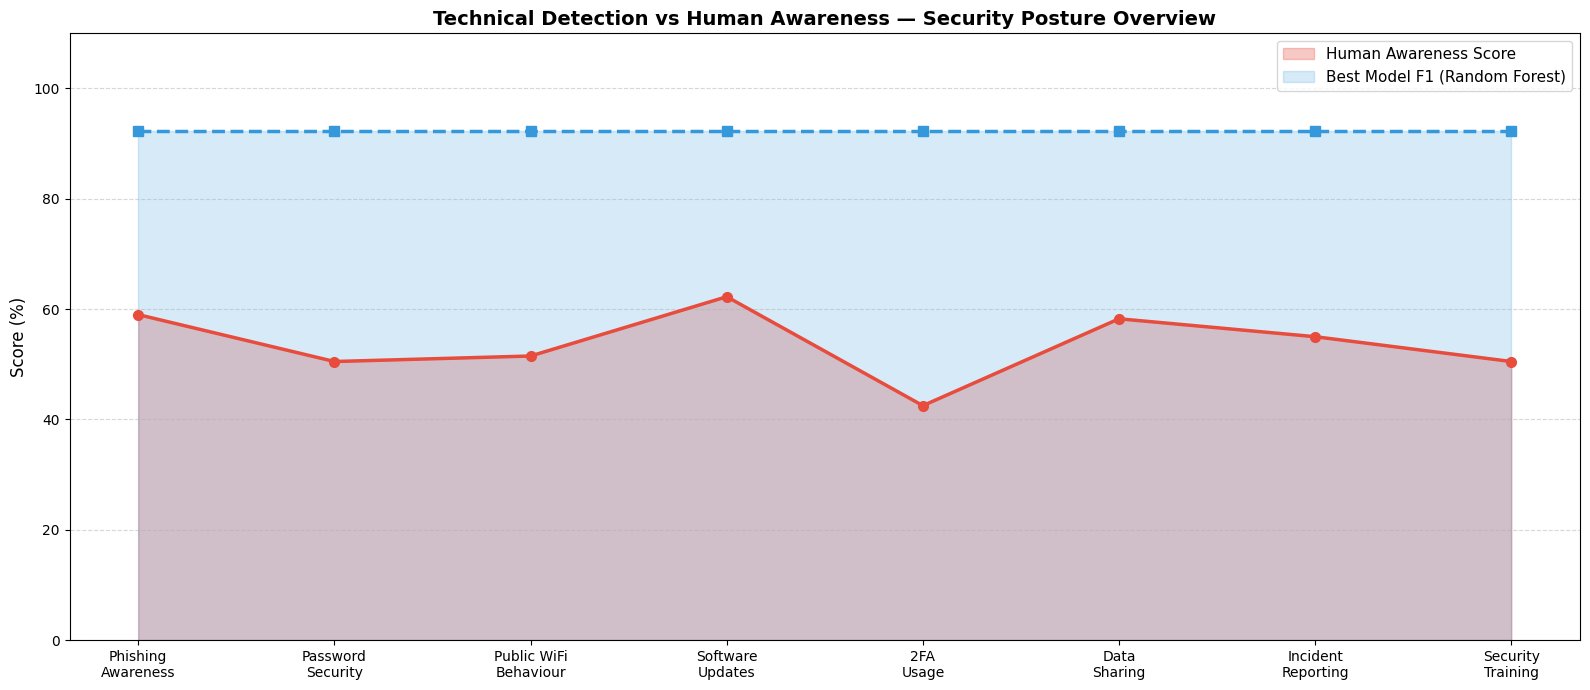

In [55]:
categories  = ['Phishing\nAwareness', 'Password\nSecurity', 'Public WiFi\nBehaviour',
                'Software\nUpdates', '2FA\nUsage', 'Data\nSharing',
                'Incident\nReporting', 'Security\nTraining']

human_scores  = [mean_scores[q] for q in score_maps.keys()]
threat_scores = [best_f1 * 100] * len(categories)

x_jt = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(16, 7))
ax.fill_between(x_jt, human_scores, alpha=0.3, color='#e74c3c', label='Human Awareness Score')
ax.fill_between(x_jt, threat_scores, alpha=0.2, color='#3498db', label=f'Best Model F1 ({best_model})')
ax.plot(x_jt, human_scores, 'o-', color='#e74c3c', lw=2.5, markersize=7)
ax.plot(x_jt, threat_scores, 's--', color='#3498db', lw=2.5, markersize=7)
ax.set_xticks(x_jt)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.set_title('Technical Detection vs Human Awareness — Security Posture Overview',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('combined_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Export Results

In [56]:
results_df.to_csv('model_performance_results.csv')
survey_data.to_csv('survey_results.csv', index=False)

print('Results exported:')
print('  model_performance_results.csv')
print('  survey_results.csv')

Results exported:
  model_performance_results.csv
  survey_results.csv


## Summary

### Summary of Findings

In [59]:
print('  CYBERSECURITY THREAT DETECTION — FINAL SUMMARY  ')
print()
print('MACHINE LEARNING MODEL PERFORMANCE (UNSW-NB15 Dataset):')
for model_name, row in results_df.iterrows():
    print(f'  {model_name:25s} | Accuracy: {row["Accuracy"]:.4f} | F1: {row["F1-Score"]:.4f} | AUC: {row["AUC-ROC"]:.4f}')

print()
print(f'  Best Performing Model : {best_model}')
print(f'  Best F1-Score         : {best_f1:.4f}')
print(f'  Best AUC-ROC          : {best_auc:.4f}')
print()
print('SECURITY AWARENESS ASSESSMENT (N=200 Respondents):')
print(f'  Average Awareness Score  : {avg_awareness:.1f}%')
print(f'  High/Very High Awareness : {high_awareness_pct:.1f}%')
print(f'  Low Awareness (Risk)     : {low_awareness_pct:.1f}%')
print()

  CYBERSECURITY THREAT DETECTION — FINAL SUMMARY  

MACHINE LEARNING MODEL PERFORMANCE (UNSW-NB15 Dataset):
  Random Forest             | Accuracy: 0.9013 | F1: 0.9226 | AUC: 0.9847
  XGBoost                   | Accuracy: 0.8948 | F1: 0.9172 | AUC: 0.9844
  SVM                       | Accuracy: 0.8500 | F1: 0.8798 | AUC: 0.9492
  Logistic Regression       | Accuracy: 0.8133 | F1: 0.8504 | AUC: 0.9342

  Best Performing Model : Random Forest
  Best F1-Score         : 0.9226
  Best AUC-ROC          : 0.9847

SECURITY AWARENESS ASSESSMENT (N=200 Respondents):
  Average Awareness Score  : 53.7%
  High/Very High Awareness : 33.5%
  Low Awareness (Risk)     : 17.5%

